In [79]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [86]:
data_train = datasets.EMNIST(root='data', split='letters', train=True, download=True, transform=transforms.ToTensor()) 
data_test = datasets.EMNIST(root='data', split='letters', train=False, download=True, transform=transforms.ToTensor())    

# ToTensor(): This transform is lazy. It doesn't overwrite the original data in memory. 
# Instead, it only applies the conversion and scaling (0 to 1) when the data is actually loaded (usually via a DataLoader or by indexing the dataset).
data_train.data.max()

tensor(255, dtype=torch.uint8)

In [89]:
data_train.targets.min(), data_train.targets.max() # they go from 1 to 26, but we want them to go from 0 to 25 for PyTorch's CrossEntropyLoss. So we need to subtract 1 from the targets.
data_train.targets -= 1
data_test.targets -= 1

In [126]:
# data_train and data_test are already PyTorch datasets, so we can directly create DataLoaders from them.

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(len(train_dataloader), len(test_dataloader))
images[0].min(), images[0].max() # check the range of pixel values (should be between 0 and 1 due to ToTensor())

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])
3900 650


(tensor(0.), tensor(1.))

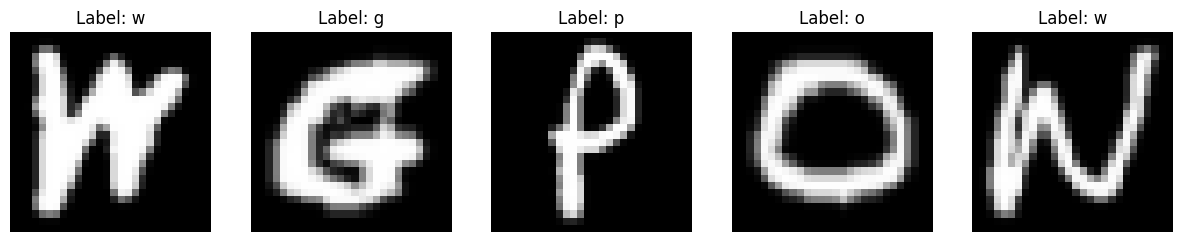

In [ ]:
# map with class_to_idx
class_names = data_train.classes
class_to_idx = data_train.class_to_idx

# visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(data_train.data[i].T, cmap='gray') # Transpose the image to correct orientation
     # Add 1 back to the target to get the original label, since the dict is built with the original labels (1-26)
    axes[i].set_title(f"Label: {class_names[data_train.targets[i].item() + 1]}")
    axes[i].axis('off')


In [94]:
class EMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # input size = (1, 28, 28)
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output size = np.floor((28 - 3 + 2*1) / 1) + 1 = 28
            # the input to batch normalization is the output of the convolutional layer, which has 6 channels (out_channels=6), even though it is called "num_features", it actually refers to the number of channels in the output of the convolutional layer
            nn.BatchNorm2d(num_features=6), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((28 - 2) / 2) + 1 = 14

            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3, stride=1, padding=1), # output size = np.floor((14 - 3 + 2*1) / 1) + 1 = 14
            nn.BatchNorm2d(num_features=6), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((14 - 2) / 2) + 1 = 7
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # flatten the output of the convolutional layers to feed into the fully connected layers
            nn.Linear(in_features=6*7*7, out_features=50),
            nn.LeakyReLU(),
            nn.Linear(in_features=50, out_features=26) # 26 classes for EMNIST letters (a-z)
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = EMNIST_CNN()
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]              60
       BatchNorm2d-2            [-1, 6, 28, 28]              12
         LeakyReLU-3            [-1, 6, 28, 28]               0
         MaxPool2d-4            [-1, 6, 14, 14]               0
            Conv2d-5            [-1, 6, 14, 14]             330
       BatchNorm2d-6            [-1, 6, 14, 14]              12
         LeakyReLU-7            [-1, 6, 14, 14]               0
         MaxPool2d-8              [-1, 6, 7, 7]               0
           Flatten-9                  [-1, 294]               0
           Linear-10                   [-1, 50]          14,750
        LeakyReLU-11                   [-1, 50]               0
           Linear-12                   [-1, 26]           1,326
Total params: 16,490
Trainable params: 16,490
Non-trainable params: 0
---------------------------------

In [95]:
# test one forward pass to see the print statements in action
model = EMNIST_CNN()
loss_fn = nn.CrossEntropyLoss() # it implements both softmax and the negative log-likelihood loss
images, labels = next(iter(train_dataloader))
output = model(images)
predicted_classes = output.argmax(dim=1)
loss = loss_fn(output, labels)
print(f"Images shape: {images.shape}")
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Loss: {loss.item()}")

Images shape: torch.Size([32, 1, 28, 28])
Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 26])
Labels shape: torch.Size([32])
Loss: 3.4257686138153076


In [ ]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0
    train_error = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, y)

        # Update training loss and error
        train_loss += loss.item()
        train_error += (outputs.argmax(dim=1) != y).sum().item() # same as accuracy but instead of == we use != to count the number of misclassifications (errors)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_error


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          ):

    train_losses_epochs = []
    test_losses_epochs = []
    train_error_epochs = []
    test_error_epochs = []

    for epoch in range(epochs):
        train_loss, train_error = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and error for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_error = train_error / len(train_dataloader.dataset)
        train_losses_epochs.append(avg_train_loss)
        train_error_epochs.append(avg_train_error)

        # Evaluate on the test set
        model.eval()
        test_loss = 0.0
        test_error = 0.0

        with torch.no_grad():
            for X, y in test_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, y)

                test_loss += loss.item()
                test_error += (outputs.argmax(dim=1) != y).sum().item()

        avg_test_loss = test_loss / len(test_dataloader)
        avg_test_error = test_error / len(test_dataloader.dataset)
        test_losses_epochs.append(avg_test_loss)
        test_error_epochs.append(avg_test_error)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Test Loss: {avg_test_loss:.4f}, "
            f"Train Error: {avg_train_error:.4f}, "
            f"Test Error: {avg_test_error:.4f}"
        )

    return train_losses_epochs, test_losses_epochs, train_error_epochs, test_error_epochs

In [99]:
model = EMNIST_CNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10
train_loss, test_loss, train_error, test_error = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.5586, Test Loss: 0.3781, Train Error: 0.1712, Test Error: 0.1200
Epoch [2/10], Train Loss: 0.3278, Test Loss: 0.3123, Train Error: 0.1058, Test Error: 0.0985
Epoch [3/10], Train Loss: 0.2867, Test Loss: 0.3066, Train Error: 0.0934, Test Error: 0.0966
Epoch [4/10], Train Loss: 0.2650, Test Loss: 0.2792, Train Error: 0.0875, Test Error: 0.0857
Epoch [5/10], Train Loss: 0.2472, Test Loss: 0.2806, Train Error: 0.0813, Test Error: 0.0875
Epoch [6/10], Train Loss: 0.2377, Test Loss: 0.2715, Train Error: 0.0802, Test Error: 0.0869
Epoch [7/10], Train Loss: 0.2284, Test Loss: 0.2658, Train Error: 0.0763, Test Error: 0.0822
Epoch [8/10], Train Loss: 0.2206, Test Loss: 0.2594, Train Error: 0.0738, Test Error: 0.0815
Epoch [9/10], Train Loss: 0.2132, Test Loss: 0.2599, Train Error: 0.0723, Test Error: 0.0809
Epoch [10/10], Train Loss: 0.2078, Test Loss: 0.2616, Train Error: 0.0708, Test Error: 0.0825


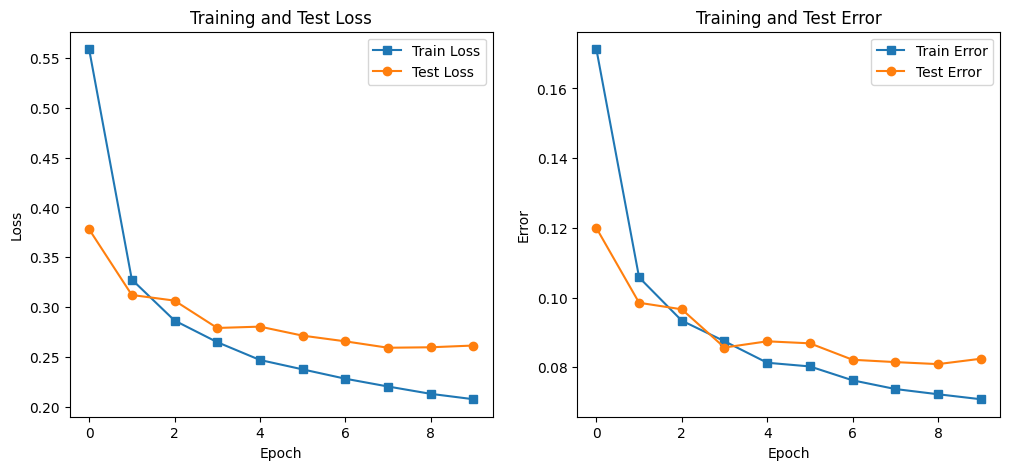

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_loss, "s-", label='Train Loss')
ax[0].plot(test_loss, "o-", label='Test Loss')
ax[0].set_title("Training and Test Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_error, "s-", label='Train Error')
ax[1].plot(test_error, "o-", label='Test Error')
ax[1].set_title("Training and Test Error")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Error")
ax[1].legend()

plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

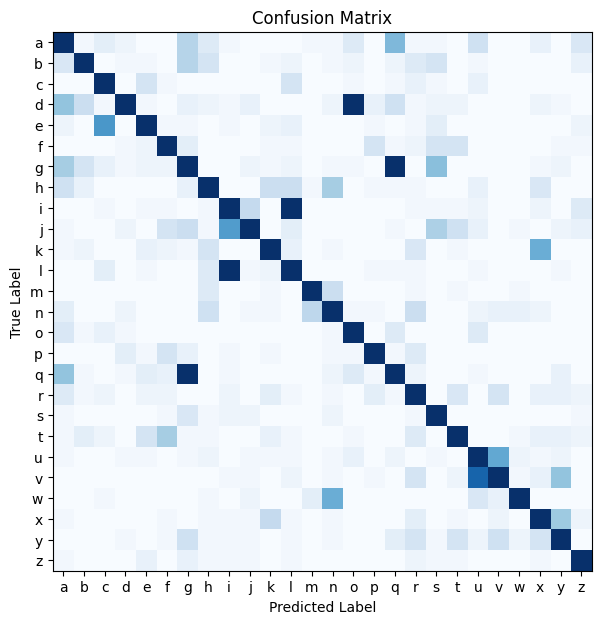

In [129]:
# create a confusion matrix with the letters of the alphabet as labels
import sklearn.metrics as skm

test_dataloader_temp = DataLoader(data_test, batch_size=len(data_test), shuffle=False) # just to get all the test data in one batch for the confusion matrix
images, targets = next(iter(test_dataloader_temp))
predictions = model(images).argmax(dim=1)
confusion_matrix = skm.confusion_matrix(targets, predictions, normalize='true') 
# normalize the confusion matrix to get the percentage of correct predictions for each class

# visualize the confusion matrix
fig = plt.figure(figsize=(7, 7))
plt.imshow(confusion_matrix, cmap='Blues', vmax = 0.05) # set vmax to 0.05 to better visualize the differences between classes (since the values are between 0 and 1)

plt.xticks(ticks=np.arange(26), labels=class_names[1:])
plt.yticks(ticks=np.arange(26), labels=class_names[1:])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")